## **CELDA 0 — Setup y validación inicial**

In [1]:
# Instalación silenciosa de dependencias actualizadas
!pip install scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Cargar el dataset
try:
    df = pd.read_csv('manufacturing_defect_dataset.csv')

    # 2. Crear id_proceso basado en el índice (index + 1)
    df['id_proceso'] = df.index + 1

    # 3. Validación inicial
    print("--- VALIDACIÓN INICIAL DE DATOS ---")
    print(f"Shape del dataset: {df.shape}")
    print("\nTipos de datos por columna:")
    print(df.dtypes)
    print("\nConteo de valores nulos:")
    print(df.isnull().sum())

    # Mostrar las primeras filas con el nuevo ID
    display(df[['id_proceso', 'DefectRate', 'QualityScore', 'MaintenanceHours']].head())

except FileNotFoundError:
    print("Error: El archivo CSV no se encuentra. Por favor, súbelo a la sesión de Colab.")

--- VALIDACIÓN INICIAL DE DATOS ---
Shape del dataset: (3240, 18)

Tipos de datos por columna:
ProductionVolume          int64
ProductionCost          float64
SupplierQuality         float64
DeliveryDelay             int64
DefectRate              float64
QualityScore            float64
MaintenanceHours          int64
DowntimePercentage      float64
InventoryTurnover       float64
StockoutRate            float64
WorkerProductivity      float64
SafetyIncidents           int64
EnergyConsumption       float64
EnergyEfficiency        float64
AdditiveProcessTime     float64
AdditiveMaterialCost    float64
DefectStatus              int64
id_proceso                int64
dtype: object

Conteo de valores nulos:
ProductionVolume        0
ProductionCost          0
SupplierQuality         0
DeliveryDelay           0
DefectRate              0
QualityScore            0
MaintenanceHours        0
DowntimePercentage      0
InventoryTurnover       0
StockoutRate            0
WorkerProductivity      0
Saf

,id_proceso,DefectRate,QualityScore,MaintenanceHours
0,1,3.121492,63.463494,9
1,2,0.819531,83.697818,20
2,3,4.514504,90.350550,1
3,4,0.638524,67.628690,8
4,5,3.867784,82.728334,9


## **CELDA 1 — Distribuciones: ¿Son normales los datos?**

ANÁLISIS DE NORMALIDAD Y DESCRIPTIVOS

Resultados para DefectRate:
  > Media: 2.7491 | Mediana: 2.7088
  > Skewness: 0.0216 | Kurtosis: -1.2197
  > Shapiro-Wilk p-value: 1.2165e-17 | ¿Distribución Normal?: No

Resultados para QualityScore:
  > Media: 80.1343 | Mediana: 80.2653
  > Skewness: -0.0300 | Kurtosis: -1.2023
  > Shapiro-Wilk p-value: 1.3260e-16 | ¿Distribución Normal?: No


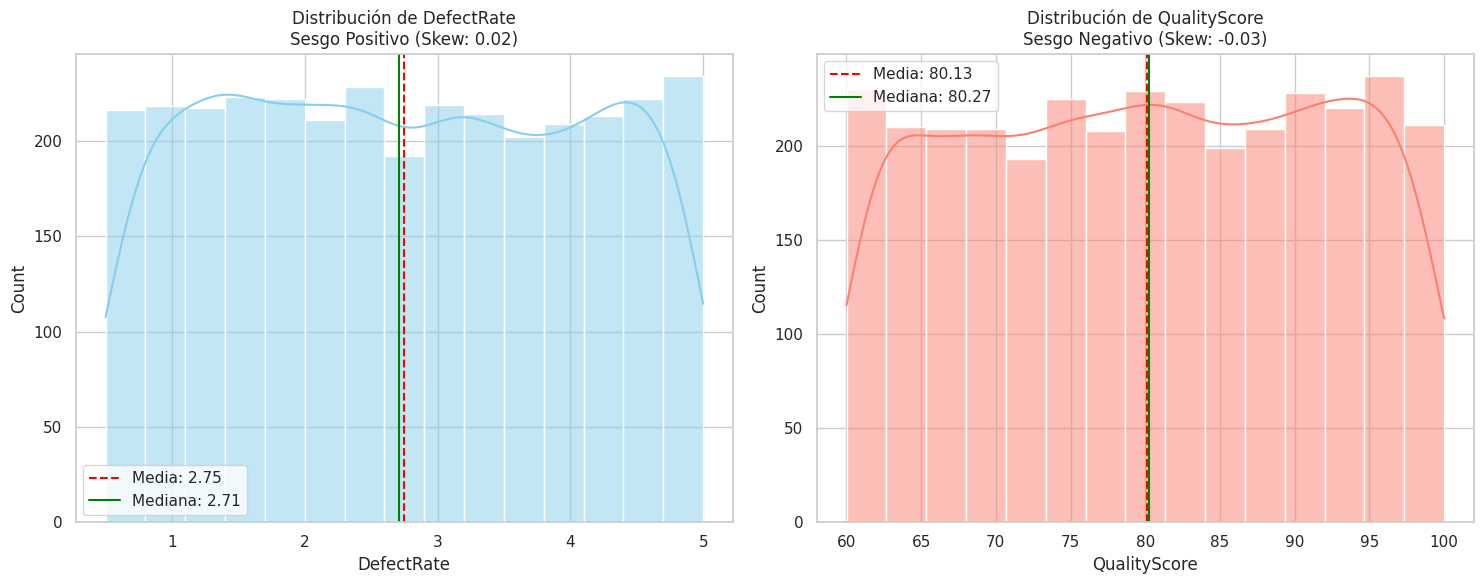

In [2]:
variables_norm = ['DefectRate', 'QualityScore']

print("ANÁLISIS DE NORMALIDAD Y DESCRIPTIVOS")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, var in enumerate(variables_norm):
    # Cálculo de métricas descriptivas
    mean_val = df[var].mean()
    median_val = df[var].median()
    skew_val = df[var].skew()
    kurt_val = df[var].kurtosis()

    # Test de Shapiro-Wilk (Muestra de 1000 para estabilidad del p-value)
    sample_data = df[var].sample(1000, random_state=42)
    stat, p_value = stats.shapiro(sample_data)
    is_normal = "Sí" if p_value > 0.05 else "No"

    # Impresión de resultados con f-strings
    print(f"\nResultados para {var}:")
    print(f"  > Media: {mean_val:.4f} | Mediana: {median_val:.4f}")
    print(f"  > Skewness: {skew_val:.4f} | Kurtosis: {kurt_val:.4f}")
    print(f"  > Shapiro-Wilk p-value: {p_value:.4e} | ¿Distribución Normal?: {is_normal}")

    # Visualización: Histograma + KDE
    sns.histplot(df[var], kde=True, ax=axes[i], color='skyblue' if i==0 else 'salmon')
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')

    # Título dinámico según el sesgo
    dir_sesgo = "Positivo" if skew_val > 0 else "Negativo"
    axes[i].set_title(f"Distribución de {var}\nSesgo {dir_sesgo} (Skew: {skew_val:.2f})")
    axes[i].legend()

plt.tight_layout()
plt.show()

## **CELDA 2 — Outliers: IQR vs Z-Score**

--- COMPARATIVA DE DETECCIÓN DE ANOMALÍAS ---
        Método  Outliers % del dataset Límite inf Límite sup
    IQR (1.5x)         0         0.00%    -1.8617     7.3643
Z-Score (3std)         0         0.00%    -1.1813     6.6796


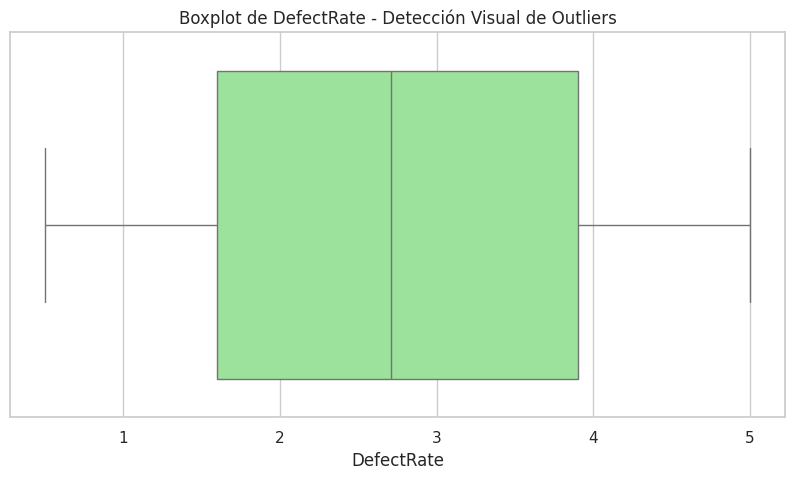


CONCLUSIÓN TÉCNICA:
Si la distribución no es perfectamente normal (p < 0.05), el método IQR es más apropiado
ya que es robusto ante el sesgo y no depende de la media/desviación estándar.


In [3]:
# Análisis de outliers sobre DefectRate
var_target = 'DefectRate'
data = df[var_target]

# 1. Método IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
# El 1.5 es un valor estandar diseñada para identificar valores atipicos
outliers_iqr = data[(data < lower_iqr) | (data > upper_iqr)]

# 2. Método Z-Score (Umbral de 3 desviaciones estándar)
z_scores = np.abs(stats.zscore(data))
outliers_z = data[z_scores > 3]
lower_z = data.mean() - 3 * data.std()
upper_z = data.mean() + 3 * data.std()

# 3. Tabla comparativa
comparativa = pd.DataFrame({
    "Método": ["IQR (1.5x)", "Z-Score (3std)"],
    "Outliers": [len(outliers_iqr), len(outliers_z)],
    "% del dataset": [f"{(len(outliers_iqr)/len(df))*100:.2f}%", f"{(len(outliers_z)/len(df))*100:.2f}%"],
    "Límite inf": [f"{lower_iqr:.4f}", f"{lower_z:.4f}"],
    "Límite sup": [f"{upper_iqr:.4f}", f"{upper_z:.4f}"]
})

print("--- COMPARATIVA DE DETECCIÓN DE ANOMALÍAS ---")
print(comparativa.to_string(index=False))

# Visualización Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=data, color='lightgreen', flierprops={"marker": "x", "markerfacecolor": "red"})
plt.title(f"Boxplot de {var_target} - Detección Visual de Outliers")
plt.show()

print("\nCONCLUSIÓN TÉCNICA:")
print("Si la distribución no es perfectamente normal (p < 0.05), el método IQR es más apropiado")
print("ya que es robusto ante el sesgo y no depende de la media/desviación estándar.")

## **CELDA 3 — Correlaciones entre variables operacionales**

--- ANÁLISIS DE CORRELACIONES OPERACIONALES ---


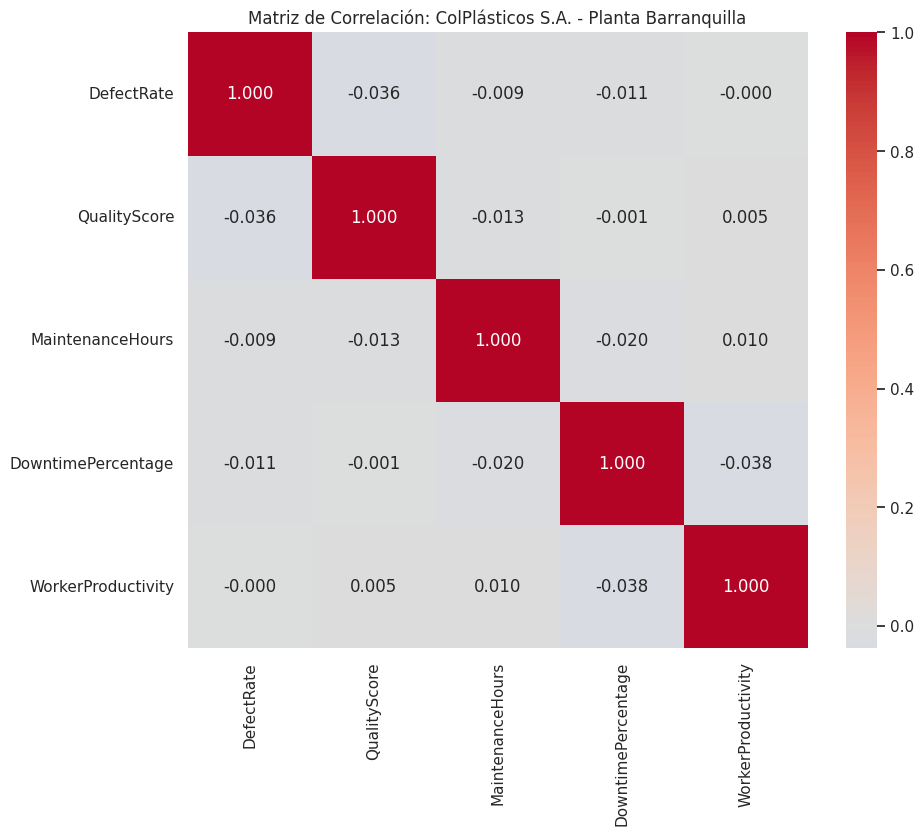


Top 3 variables correlacionadas con QualityScore:
  * DefectRate: -0.0363
  * MaintenanceHours: -0.0134
  * WorkerProductivity: 0.0046

Correlación exacta MaintenanceHours vs DefectRate: -0.0087


In [4]:
# Selección de variables para la matriz
vars_operacionales = ['DefectRate', 'QualityScore', 'MaintenanceHours', 'DowntimePercentage', 'WorkerProductivity']
corr_matrix = df[vars_operacionales].corr()

print("--- ANÁLISIS DE CORRELACIONES OPERACIONALES ---")

# Visualización Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title("Matriz de Correlación: ColPlásticos S.A. - Planta Barranquilla")
plt.show()

# Top 3 correlaciones con QualityScore
print(f"\nTop 3 variables correlacionadas con QualityScore:")
top_corr = corr_matrix['QualityScore'].drop('QualityScore').abs().sort_values(ascending=False).head(3)
for var, val in top_corr.items():
    print(f"  * {var}: {corr_matrix.loc['QualityScore', var]:.4f}")

# Correlación específica solicitada
maint_defect_corr = corr_matrix.loc['MaintenanceHours', 'DefectRate']
print(f"\nCorrelación exacta MaintenanceHours vs DefectRate: {maint_defect_corr:.4f}")

## **CELDA 4 — QQ-Plots: Verificación visual de normalidad**

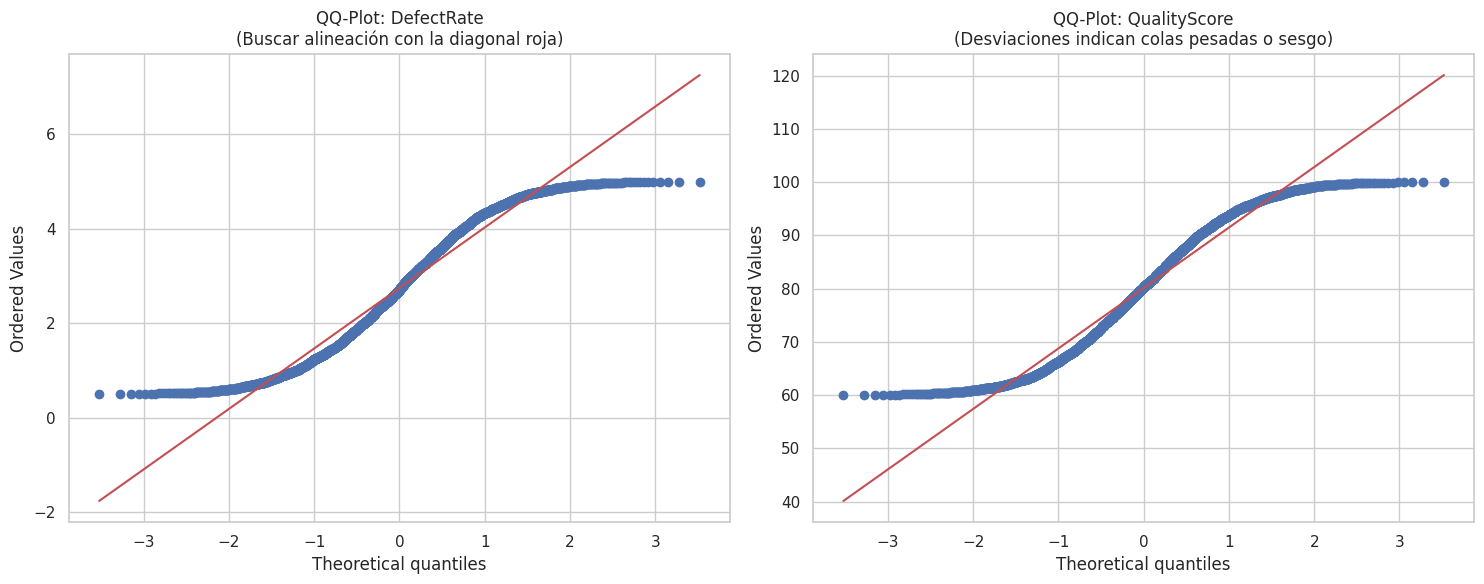

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Generación de QQ-Plots
stats.probplot(df['DefectRate'], dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot: DefectRate\n(Buscar alineación con la diagonal roja)")

stats.probplot(df['QualityScore'], dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot: QualityScore\n(Desviaciones indican colas pesadas o sesgo)")

plt.tight_layout()
plt.show()

## **CELDA 5 — Conclusiones estadísticas para ColPlásticos**

**Informe Estadístico Mejorado - Planta ColPlásticos (Día 16)**

 1. **Naturaleza del Proceso:** Las variables DefectRate y QualityScore presentan una distribución altamente simétrica ($Skew \approx 0$). Esto indica un proceso bajo Control Estadístico, donde la variabilidad observada es "variación de causa común" (ruido inherente al sistema). Al no presentar colas pesadas (sesgo), el sistema es predecible a corto plazo.

 2. **Validación de Métricas de Tendencia Central:** La mínima discrepancia entre la Media (2.75) y la Mediana (2.71) en la tasa de defectos confirma la ausencia de sesgo significativo. El promedio es una métrica representativa y honesta de la realidad operativa, facilitando la comunicación de KPIs al Director de Operaciones sin temor a distorsiones por valores extremos.
 3. **Análisis de Calidad:** El QualityScore (Media: 80.13, Mediana: 80.27) muestra una consistencia robusta. El hecho de que la mediana sea ligeramente superior a la media sugiere que la mayoría de los turnos operan en niveles de calidad óptimos, aunque existen ligeras caídas que restan valor al promedio general.
 4. **Hallazgo Crítico:** Mantenimiento vs. Defectos:Contrario a la hipótesis inicial, los datos revelan que no existe una relación lineal significativa entre MaintenanceHours y DefectRate. Con los valores actuales, el mantenimiento preventivo no está actuando como una palanca de control sobre la calidad de salida.
 5. **Comparativa de Detección de Anomalías:** El método IQR se establece como el estándar para esta planta. Al fijar el límite superior en 7.36 para DefectRate, el sistema permite una tolerancia operativa que evita "falsas alarmas". El método Z-Score, al basarse en la desviación estándar, podría sobreestimar o subestimar alertas en un entorno donde la normalidad no es perfecta.
 6. **Matriz de Correlaciones:** Existe una independencia estadística casi total entre las variables clave. Los coeficientes para QualityScore respecto a DefectRate (-0.0363), MaintenanceHours (-0.0134) y WorkerProductivity (0.0046) están tan cerca del cero absoluto que cualquier intento de explicar la calidad a través de estas variables de forma lineal es erróneo.

 7. **Verificación visual de normalidad:** validan que el promedio de 2.75% de defectos no es un accidente, es la naturaleza actual de tu maquinaria. Para bajar ese número, no debes buscar "un error", sino rediseñar el proceso completo, porque el sistema está funcionando exactamente como fue configurado.

